# Single-Window Forecast: Multi-Checkpoint Comparison

This notebook extracts the single-window forecast comparison from `forecasting_induced_eq_triplet.ipynb` and puts multiple checkpoints into one figure.

Recommended layout:
- Use one row per checkpoint for 4 or 6 checkpoints; this preserves the full time axis and makes trajectories easier to compare.
- Remove the right-side forecast-count histogram subplot; keep only a compact row annotation with mean/median/95% count interval.
- Keep a thin right y-axis for cumulative count because the forecast trajectories are counting-process paths, not magnitude points.
- Use `N_COLS = 2` only for slides or compact drafts; for paper figures, `N_COLS = 1` is usually cleaner.

## 1) Setup

In [1]:
import gc
import inspect
import sys
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Cannot find project root containing src directory.')


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models.updaters import UpdaterSamplingWrapper, build_sampling_updater
from src.train.config_setup import load_and_prepare_model
from src.utils.forecast_eval import apply_publication_style, save_pub_figure
from src.utils.runtime_utils import unwrap_compiled_model
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.utils import set_seed
from src.utils.viz_sequences import plot_counting_process, visualize_sequence

apply_publication_style()
set_seed(0)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / 'forecast_nxm'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0
OUTPUT_DIR: /root/autodl-tmp/em_eqf/notebooks/figs/forecast_nxm


## 2) Checkpoints

In [2]:
MODEL_SPECS = [
    {
        'label': 'ETAS + p',
        'path': 'experiments/etas_multi_ds_bg_split_0.7/runs/etas__PNR_1z_proportional_seed_1/best_model_1.pth',
    },
    {
        'label': 'ETAS + conv',
        'path': 'experiments/etas_multi_ds_bg_split_0.7/runs/etas__PNR_1z_kernel_seed_1/best_model_1.pth',
    },

    {
        'label': 'ETAS + mamba',
        'path': 'experiments/etas_multi_ds_bg_split_0.7/runs/etas__PNR_1z_mamba_seed_1/best_model_1.pth',
    },
    
    {
        'label': 'RECAST + p',
        'path': 'experiments/rtpp_v2_multi_bg_split_0.7/runs/rtpp_v2_bg_PNR_1z_proportional_seed_1/best_model_1.pth',
    },
    {
        'label': 'RECAST + conv',
        'path': 'experiments/rtpp_v2_multi_bg_split_0.7/runs/rtpp_v2_bg_PNR_1z_kernel_seed_1/best_model_1.pth',
    },
    {
        'label': 'RECAST + mamba',
        'path': 'experiments/rtpp_v2_multi_bg_split_0.7/runs/rtpp_v2_bg_PNR_1z_mamba_seed_1/best_model_1.pth',
    },

]

OPTIONAL_CKPT_SPECS = [

]

USE_OPTIONAL_CKPTS = True
CKPT_SPECS = MODEL_SPECS + (OPTIONAL_CKPT_SPECS if USE_OPTIONAL_CKPTS else [])


def resolve_ckpt_path(path_like) -> Path:
    path = Path(path_like).expanduser()
    return path if path.is_absolute() else PROJECT_ROOT / path


for spec in CKPT_SPECS:
    ckpt_path = resolve_ckpt_path(spec['path'])
    status = 'OK' if ckpt_path.exists() else 'MISSING'
    print(f'{status}: {spec["label"]}: {ckpt_path}')

OK: ETAS + p: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__PNR_1z_proportional_seed_1/best_model_1.pth
OK: ETAS + conv: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__PNR_1z_kernel_seed_1/best_model_1.pth
OK: ETAS + mamba: /root/autodl-tmp/em_eqf/experiments/etas_multi_ds_bg_split_0.7/runs/etas__PNR_1z_mamba_seed_1/best_model_1.pth
OK: RECAST + p: /root/autodl-tmp/em_eqf/experiments/rtpp_v2_multi_bg_split_0.7/runs/rtpp_v2_bg_PNR_1z_proportional_seed_1/best_model_1.pth
OK: RECAST + conv: /root/autodl-tmp/em_eqf/experiments/rtpp_v2_multi_bg_split_0.7/runs/rtpp_v2_bg_PNR_1z_kernel_seed_1/best_model_1.pth
OK: RECAST + mamba: /root/autodl-tmp/em_eqf/experiments/rtpp_v2_multi_bg_split_0.7/runs/rtpp_v2_bg_PNR_1z_mamba_seed_1/best_model_1.pth


## 3) Single-Window Settings

In [3]:
T_FORECAST = 50
FORECAST_DURATION = 10
NUM_SAMPLES = 1000
SAMPLES_PER_BATCH = min(NUM_SAMPLES, 1000)
SAMPLE_SEED = 3
USE_SHARED_SAMPLE_SEED = True

NUM_EXAMPLES = 18
EXAMPLE_OFFSET = 0
T_BEFORE = 0

USE_TORCH_COMPILE = False
MODEL_MM = 4

FORECAST_B_SAMPLING = 'model'
UPDATER_NAME = 'bayesian_gr'
UPDATER_CFG = {
    'delta': 0.98,
    'a0': 50,
    'init_b_target': 1,
}

window_start = float(T_FORECAST)
window_end = float(T_FORECAST + FORECAST_DURATION)
print(f'Forecast window: [{window_start:g}, {window_end:g}]')
print(f'Forecast samples per checkpoint: {NUM_SAMPLES}')

Forecast window: [50, 60]
Forecast samples per checkpoint: 1000


## 4) Load Catalog and Window

In [4]:
bootstrap_path = resolve_ckpt_path(CKPT_SPECS[0]['path'])
bootstrap_model, bootstrap_args = load_and_prepare_model(
    checkpoint_path=bootstrap_path,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
bootstrap_model = unwrap_compiled_model(bootstrap_model)

catalog_cfg = getattr(bootstrap_args, 'catalog_cfg', {})
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    bootstrap_args.dataset,
    base_dir=PROJECT_ROOT / 'data' / bootstrap_args.dataset,
    catalog_cfg=catalog_cfg,
)

del bootstrap_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

full_seq = catalog_ds.full_sequence
sequences = catalog_ds.sequences if hasattr(catalog_ds, 'sequences') else [full_seq]
SEQUENCE_IDX = 0
seq = sequences[SEQUENCE_IDX]
mc = catalog_ds.metadata['mag_completeness']

past_seq = seq.get_subsequence(0, T_FORECAST, reset_t_nll_to_end=True)
observed_seq = seq.get_subsequence(T_FORECAST, T_FORECAST + FORECAST_DURATION, reset_t_nll_to_end=True)

metadata_start = catalog_ds.metadata.get('start_ts', 'start')
date_label = metadata_start.strftime('%Y-%m-%d') if hasattr(metadata_start, 'strftime') else str(metadata_start)

print(f'Catalog registry name: {registry_name}')
print(f'Dataset: {bootstrap_args.dataset}')
print(f'Sequence index: {SEQUENCE_IDX}')
print(f'Observed events in window: {len(observed_seq)}')
print(f'Magnitude completeness: {mc}')

Catalog registry name: PNR_1z-Standard
Dataset: PNR_1z
Sequence index: 0
Observed events in window: 1168
Magnitude completeness: -1.5


## 5) Forecast Sampling Helpers

In [5]:
def supports_dynamic_b_sampling(model) -> bool:
    try:
        parameters = inspect.signature(model.sample).parameters
        if any(name in parameters for name in ('b_sampling', 'updater', 'updater_name', 'updater_cfg')):
            return True
    except Exception:
        pass
    return hasattr(model, '_normalize_b_sampling_mode')


def prepare_model_for_sampling(model, args):
    if MODEL_MM is not None and hasattr(model, 'M_m'):
        model.M_m = torch.tensor(float(MODEL_MM), device=DEVICE)
    predict_b = bool(getattr(args, 'predict_b', False))
    if hasattr(model, 'predict_b'):
        model.predict_b = predict_b
    return predict_b


def make_sampling_model(model, mc_value):
    if FORECAST_B_SAMPLING != 'updater':
        return model, 'model'
    if not supports_dynamic_b_sampling(model):
        print(f'{type(model).__name__} does not support updater b sampling; using model b.')
        return model, 'model'

    def updater_factory():
        return build_sampling_updater(
            model=model,
            mc=float(mc_value),
            updater_name=UPDATER_NAME,
            updater_cfg=dict(UPDATER_CFG or {}),
            device=getattr(model, 'device', DEVICE),
        )

    wrapped_model = UpdaterSamplingWrapper(
        model,
        sampling_mode=FORECAST_B_SAMPLING,
        updater_factory=updater_factory,
    )
    return wrapped_model, FORECAST_B_SAMPLING


def move_forecasts_to_cpu(forecasts):
    return [forecast.cpu() if hasattr(forecast, 'cpu') else forecast for forecast in forecasts]


def summarize_forecasts(label, ckpt_path, args, forecasts, predict_b, b_sampling):
    counts = np.asarray([len(forecast) for forecast in forecasts], dtype=float)
    q025, q50, q975 = np.quantile(counts, [0.025, 0.5, 0.975]) if counts.size else (np.nan, np.nan, np.nan)
    zero_inter_time_count = 0
    for forecast in forecasts:
        inter_times = torch.as_tensor(forecast.inter_times).detach().cpu()
        zero_inter_time_count += int((inter_times == 0).any().item())
    return {
        'label': label,
        'model': str(getattr(args, 'model', '')),
        'dataset': str(getattr(args, 'dataset', '')),
        'predict_b': predict_b,
        'b_sampling': b_sampling,
        'num_samples': len(forecasts),
        'obs_count': len(observed_seq),
        'mean_count': float(np.mean(counts)) if counts.size else np.nan,
        'median_count': float(q50),
        'q025_count': float(q025),
        'q975_count': float(q975),
        'count_abs_error_mean': float(abs(np.mean(counts) - len(observed_seq))) if counts.size else np.nan,
        'zero_inter_time_forecasts': zero_inter_time_count,
        'checkpoint': str(ckpt_path),
    }


def sample_forecasts_for_checkpoint(spec, index):
    label = spec['label']
    ckpt_path = resolve_ckpt_path(spec['path'])
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')

    print(f'[{index + 1}/{len(CKPT_SPECS)}] Loading {label}')
    model, args = load_and_prepare_model(
        checkpoint_path=ckpt_path,
        device=DEVICE,
        compile=USE_TORCH_COMPILE,
    )
    model = unwrap_compiled_model(model)

    if str(getattr(args, 'dataset', '')) != str(bootstrap_args.dataset):
        print(f'Warning: {label} dataset={getattr(args, "dataset", None)} differs from bootstrap dataset={bootstrap_args.dataset}')

    predict_b = prepare_model_for_sampling(model, args)
    sampling_model, b_sampling = make_sampling_model(model, mc)
    past_seq_device = past_seq.to(DEVICE) if torch.cuda.is_available() else past_seq

    forecasts = sample_tpp_forecasts(
        model=sampling_model,
        past_seq=past_seq_device,
        duration=FORECAST_DURATION,
        num_samples=NUM_SAMPLES,
        samples_per_batch=SAMPLES_PER_BATCH,
        bg_cache_seq=seq,
        seed=SAMPLE_SEED if USE_SHARED_SAMPLE_SEED else SAMPLE_SEED + index,
        predict_b=predict_b,
    )
    forecasts = move_forecasts_to_cpu(forecasts)
    summary = summarize_forecasts(label, ckpt_path, args, forecasts, predict_b, b_sampling)

    del sampling_model
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f'  sampled={len(forecasts)}, mean_count={summary["mean_count"]:.2f}, 95%=[{summary["q025_count"]:.0f}, {summary["q975_count"]:.0f}]')
    return forecasts, summary

## 6) Run Forecasts

In [6]:
forecasts_by_label = OrderedDict()
summary_rows = []

for ckpt_index, ckpt_spec in enumerate(CKPT_SPECS):
    ckpt_forecasts, ckpt_summary = sample_forecasts_for_checkpoint(ckpt_spec, ckpt_index)
    forecasts_by_label[ckpt_spec['label']] = ckpt_forecasts
    summary_rows.append(ckpt_summary)

summary_df = pd.DataFrame(summary_rows)
summary_df

[1/6] Loading ETAS + p


  0%|          | 0/1000 [00:00<?, ?it/s]

/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 2 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 3 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/em_eqf/src/data/sequence.py:370: UserWarning: Found 2 zero inter-ev

  sampled=1000, mean_count=1431.26, 95%=[1063, 1905]
[2/6] Loading ETAS + conv


  0%|          | 0/1000 [00:00<?, ?it/s]

  sampled=1000, mean_count=1138.70, 95%=[763, 1624]
[3/6] Loading ETAS + mamba


  0%|          | 0/1000 [00:00<?, ?it/s]

  sampled=1000, mean_count=943.19, 95%=[681, 1270]
[4/6] Loading RECAST + p
  sampled=1000, mean_count=1270.52, 95%=[403, 1781]
[5/6] Loading RECAST + conv
  sampled=1000, mean_count=1131.79, 95%=[447, 1886]
[6/6] Loading RECAST + mamba
  sampled=1000, mean_count=1312.12, 95%=[501, 2218]


,label,model,dataset,predict_b,b_sampling,num_samples,obs_count,mean_count,median_count,q025_count,q975_count,count_abs_error_mean,zero_inter_time_forecasts,checkpoint
0,ETAS + p,etas,PNR_1z,False,model,1000,1168,1431.263,1409.5,1063.000,1905.200,263.263,481,/root/autodl-tmp/em_eqf/experiments/etas_multi...
1,ETAS + conv,etas,PNR_1z,False,model,1000,1168,1138.698,1120.0,762.975,1624.200,29.302,138,/root/autodl-tmp/em_eqf/experiments/etas_multi...
2,ETAS + mamba,etas,PNR_1z,False,model,1000,1168,943.194,933.5,680.975,1270.025,224.806,404,/root/autodl-tmp/em_eqf/experiments/etas_multi...
3,RECAST + p,rtpp_v2,PNR_1z,False,model,1000,1168,1270.518,1321.0,402.925,1781.050,102.518,0,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...
4,RECAST + conv,rtpp_v2,PNR_1z,False,model,1000,1168,1131.792,1097.5,446.825,1886.275,36.208,0,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...
5,RECAST + mamba,rtpp_v2,PNR_1z,False,model,1000,1168,1312.116,1302.5,500.900,2218.400,144.116,0,/root/autodl-tmp/em_eqf/experiments/rtpp_v2_mu...


## 7) Plot Without the Right Histogram Subplot

In [7]:
def selected_forecasts(forecasts, num_examples, offset):
    if not forecasts:
        return []
    safe_offset = max(0, min(int(offset), len(forecasts) - 1))
    safe_num_examples = min(int(num_examples), len(forecasts) - safe_offset)
    return forecasts[safe_offset:safe_offset + safe_num_examples]


def count_stats_text(forecasts, observed_count):
    counts = np.asarray([len(forecast) for forecast in forecasts], dtype=float)
    if counts.size == 0:
        return f'obs={observed_count}\nno forecasts'
    q025, q50, q975 = np.quantile(counts, [0.025, 0.5, 0.975])
    return f'mean={counts.mean():.1f}, med={q50:.0f}\n95%=[{q025:.0f}, {q975:.0f}], obs={observed_count}'


def common_count_limit(forecasts_by_model, observed_count, num_examples, offset):
    candidates = [float(observed_count), 1.0]
    for forecasts in forecasts_by_model.values():
        counts = np.asarray([len(forecast) for forecast in forecasts], dtype=float)
        if counts.size:
            candidates.append(float(np.quantile(counts, 0.975)))
        candidates.extend(float(len(forecast)) for forecast in selected_forecasts(forecasts, num_examples, offset))
    return max(candidates) * 1.08


def plot_single_window_ckpt_comparison(
    seq,
    forecasts_by_model,
    observed_seq,
    *,
    t_start,
    t_end,
    t_before,
    num_examples,
    offset=0,
    ncols=1,
    figsize=None,
    xlabel='Days since start',
):
    labels = list(forecasts_by_model.keys())
    if not labels:
        raise ValueError('forecasts_by_model must be non-empty')

    ncols = max(1, int(ncols))
    nrows = int(np.ceil(len(labels) / ncols))
    if figsize is None:
        row_height = 1.9 if ncols == 1 else 2.25
        width = 9.4 if ncols == 1 else 10.8
        figsize = (width, max(3.2, row_height * nrows + 0.7))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        constrained_layout=True,
        squeeze=False,
    )

    plot_colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    default_forecast_color = plot_colors[1] if len(plot_colors) > 1 else '#F28E2B'
    s_viz = seq.get_subsequence(t_start - t_before, t_end, reset_t_nll_to_end=True).cpu()
    s_obs = observed_seq.cpu() if hasattr(observed_seq, 'cpu') else observed_seq
    observed_count = len(s_obs)
    count_ymax = common_count_limit(forecasts_by_model, observed_count, num_examples, offset)
    count_axes = []

    for panel_index, label in enumerate(labels):
        row = panel_index // ncols
        col = panel_index % ncols
        ax = axes[row, col]
        forecast_color = default_forecast_color
        forecasts = forecasts_by_model[label]

        if t_before > 0:
            ax.axvspan(t_start, t_end, color='#C2D9F8', alpha=0.22, lw=0)
        ax.axvline(t_start, color='black', lw=0.9, ls='--', alpha=0.75)
        visualize_sequence(
            s_viz,
            ax=ax,
            event_color='0.25',
            mag_completeness=mc,
            t_start=t_start - t_before,
            t_end=t_end,
            show_legend=False,
            xlabel=xlabel,
        )
        ax.set_xlim(t_start - t_before, t_end)
        ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.6)
        ax.tick_params(axis='both', labelsize=8)
        ax.set_ylabel('Magnitude', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax_count = ax.twinx()
        plot_counting_process(
            s_obs,
            ax_count,
            color='black',
            alpha=0.95,
            T0=t_start,
            T=t_end,
            linewidth=1.8,
            zorder=5,
        )
        for forecast in selected_forecasts(forecasts, num_examples, offset):
            forecast_cpu = forecast.cpu() if hasattr(forecast, 'cpu') else forecast
            plot_counting_process(
                forecast_cpu,
                ax_count,
                color=forecast_color,
                alpha=0.42,
                T0=t_start,
                T=t_end,
                linewidth=1.1,
                zorder=2,
            )
        ax_count.set_ylim(0, count_ymax)
        ax_count.tick_params(axis='y', labelsize=8)
        ax_count.grid(False)
        count_axes.append(ax_count)

        panel_label = f'({chr(ord("a") + panel_index)}) {label}'
        ax.text(
            0.012,
            0.96,
            panel_label,
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=9,
            fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=2.0),
        )
        ax.text(
            0.988,
            0.85,
            count_stats_text(forecasts, observed_count),
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=8,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=2.0),
        )

        if col == ncols - 1:
            ax_count.set_ylabel('Cumulative count', fontsize=9)
        else:
            ax_count.set_ylabel('')
            ax_count.tick_params(axis='y', labelright=False)
        if row < nrows - 1:
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelbottom=False)

    for empty_index in range(len(labels), nrows * ncols):
        row = empty_index // ncols
        col = empty_index % ncols
        axes[row, col].set_axis_off()

    legend_handles = []
    if t_before > 0:
        legend_handles.append(Patch(facecolor='#C2D9F8', edgecolor='none', alpha=0.22, label='Forecast window'))
    legend_handles.extend([
        Line2D([0], [0], color='black', lw=1.8, label='Observed count'),
        Line2D([0], [0], color=default_forecast_color, lw=1.2, alpha=0.6, label='Sample forecast counts'),
    ])
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.012),
    )
    return fig, axes, count_axes

## 8) Recommended Figure

Saved: /root/autodl-tmp/em_eqf/notebooks/figs/forecast_nxm/single_window_ckpt_comparison_rows.pdf
Saved: /root/autodl-tmp/em_eqf/notebooks/figs/forecast_nxm/single_window_ckpt_comparison_rows.png


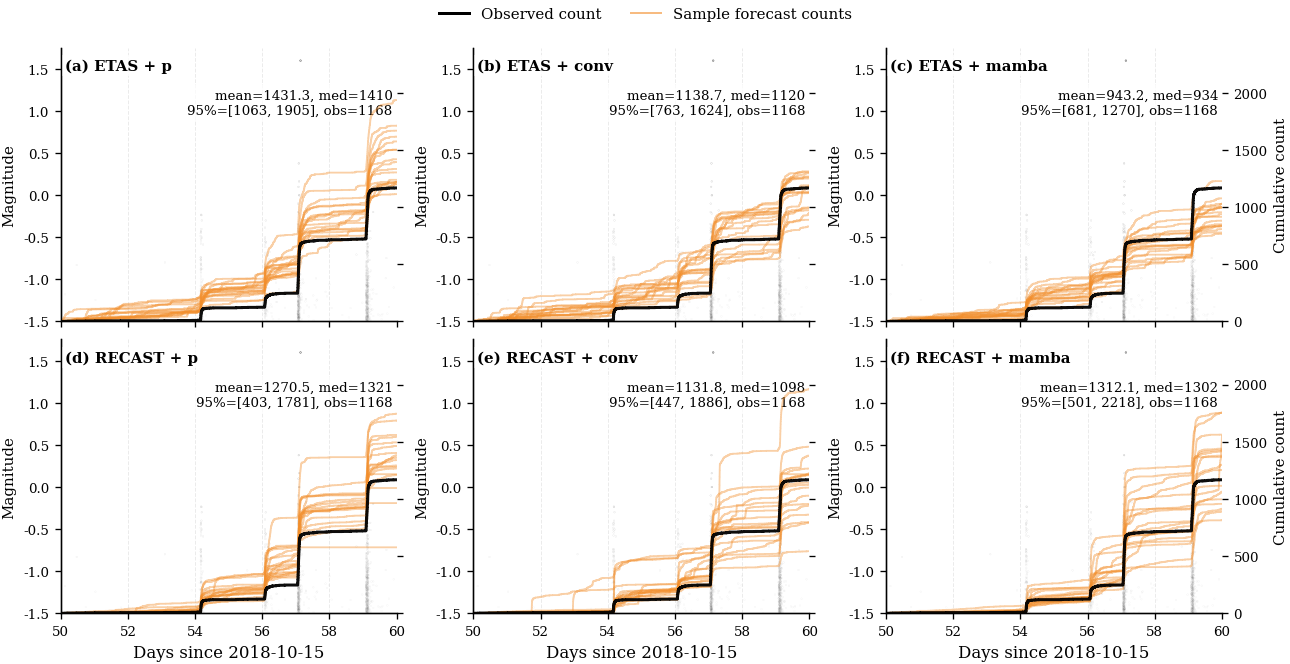

In [8]:
N_COLS = 3

fig, axes, count_axes = plot_single_window_ckpt_comparison(
    seq,
    forecasts_by_label,
    observed_seq,
    t_start=window_start,
    t_end=window_end,
    t_before=T_BEFORE,
    num_examples=NUM_EXAMPLES,
    offset=EXAMPLE_OFFSET,
    ncols=N_COLS,
    xlabel='Days since ' + date_label,
)

pdf_path = save_pub_figure(fig, OUTPUT_DIR / 'single_window_ckpt_comparison_rows', file_format='pdf')
png_path = save_pub_figure(fig, OUTPUT_DIR / 'single_window_ckpt_comparison_rows', file_format='png')
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')
plt.show()

## 9) Optional Compact Layout

In [9]:
MAKE_COMPACT_LAYOUT = False

if MAKE_COMPACT_LAYOUT:
    compact_fig, compact_axes, compact_count_axes = plot_single_window_ckpt_comparison(
        seq,
        forecasts_by_label,
        observed_seq,
        t_start=window_start,
        t_end=window_end,
        t_before=T_BEFORE,
        num_examples=NUM_EXAMPLES,
        offset=EXAMPLE_OFFSET,
        ncols=2,
        xlabel='Days since ' + date_label,
    )
    compact_pdf_path = save_pub_figure(compact_fig, OUTPUT_DIR / 'single_window_ckpt_comparison_grid', file_format='pdf')
    compact_png_path = save_pub_figure(compact_fig, OUTPUT_DIR / 'single_window_ckpt_comparison_grid', file_format='png')
    print(f'Saved: {compact_pdf_path}')
    print(f'Saved: {compact_png_path}')
    plt.show()